# PricePredictor — Modélisation et évaluation honnête (2/3)

**Data Analyst — Finance, Business Intelligence et Aide à la décision**

L'exploration précédente a montré que les rendements journaliers d'AAPL se comportent, sur cet échantillon, comme un bruit quasi blanc. Ce notebook teste malgré tout si des variables construites (rendements décalés, volatilité glissante, volume) permettent à un modèle simple de faire mieux qu'une prédiction naïve.

**Règle non négociable pour une série temporelle :** aucun mélange aléatoire train/test. Le split est chronologique — le modèle n'apprend jamais sur des données futures par rapport à ce qu'il prédit.


In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

conn = sqlite3.connect("stockdb.sqlite")
df = pd.read_sql_query(
    "SELECT date_cours, cours_cloture, volume FROM cours WHERE ticker='AAPL' ORDER BY date_cours", conn
)
conn.close()
df["date_cours"] = pd.to_datetime(df["date_cours"])
df["rendement"] = df["cours_cloture"].pct_change()


## 1. Construction des variables explicatives

Chaque variable n'utilise que de l'information disponible **avant** le jour cible — condition indispensable pour éviter toute fuite d'information (data leakage) qui gonflerait artificiellement la performance apparente du modèle.

In [2]:
df["ret_lag1"] = df["rendement"].shift(1)
df["ret_lag2"] = df["rendement"].shift(2)
df["ret_lag5"] = df["rendement"].shift(5)
df["vol_roll10"] = df["rendement"].shift(1).rolling(10).std()

vol_shift = df["volume"].shift(1)
df["volume_norm"] = (vol_shift - vol_shift.rolling(20).mean()) / vol_shift.rolling(20).std()

features = ["ret_lag1", "ret_lag2", "ret_lag5", "vol_roll10", "volume_norm"]
data = df.dropna(subset=features + ["rendement"]).reset_index(drop=True)
data[["date_cours"] + features + ["rendement"]].tail()


## 2. Split temporel et modèles

- **Baseline naïve** : rendement prédit = 0 (équivaut à "le prix de demain égale le prix d'aujourd'hui")
- **Régression linéaire** : combinaison linéaire des 5 variables
- **Random Forest** (profondeur limitée à 4 pour un échantillon de cette taille) : permet en plus de lire l'importance de chaque variable

In [3]:
X = data[features].values
y = data["rendement"].values
dates = data["date_cours"].values

split_idx = int(len(data) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_test = dates[split_idx:]

pred_naive = np.zeros_like(y_test)

lin = LinearRegression().fit(X_train, y_train)
pred_lin = lin.predict(X_test)

rf = RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42).fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print(f"Observations entrainement : {len(X_train)} | Observations test : {len(X_test)}")


Observations entrainement : 48 | Observations test : 12


## 3. Évaluation — RMSE, MAE, précision directionnelle

La précision directionnelle (% de fois où le signe prédit correspond au signe réel) est la métrique la plus parlante pour un usage pratique : peu importe l'ampleur, avoir le bon sens de variation est ce qui compte pour une décision d'achat/vente.

In [4]:
def eval_model(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    dir_acc = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
    return {"Modele": name, "RMSE": rmse, "MAE": mae, "Precision directionnelle (%)": dir_acc}

resultats = pd.DataFrame([
    eval_model(y_test, pred_naive, "Baseline naive (rendement = 0)"),
    eval_model(y_test, pred_lin, "Regression lineaire"),
    eval_model(y_test, pred_rf, "Random Forest"),
]).round(4)
resultats


Modele,RMSE,MAE,Precision directionnelle (%)
Baseline naive (rendement = 0),0.0210,0.0154,0.0000
Regression lineaire,0.0214,0.0174,41.6667
Random Forest,0.0197,0.0143,58.3333


**Lecture (à interpréter avec prudence — 12 observations de test seulement) :**

- Le **Random Forest** obtient le RMSE le plus bas et une précision directionnelle de 58 % — légèrement au-dessus du hasard (50 %).
- La **régression linéaire** fait *moins bien* que la baseline en RMSE, et sa précision directionnelle (42 %) est en dessous du hasard sur cet échantillon.
- La baseline affiche 0 % de précision directionnelle par construction : elle prédit toujours un rendement nul, donc son signe ne correspond jamais à un rendement réel non nul. **Ce n'est pas un échec du modèle** — la baseline ne prend simplement aucun pari directionnel. Elle sert de référence sur le RMSE, pas sur cette métrique.

**Avec seulement 12 observations de test, cet écart entre modèles n'est pas statistiquement significatif.** Il faudrait un historique de plusieurs années pour trancher sérieusement entre "le Random Forest capte un signal réel" et "cette différence est due au hasard de l'échantillon".

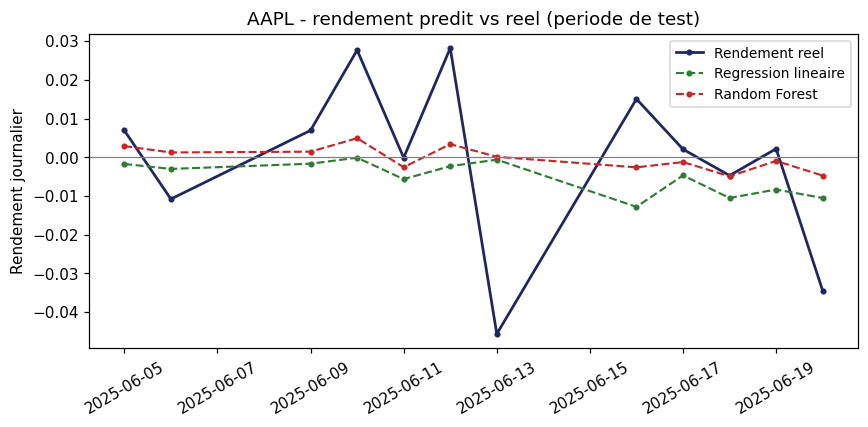

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dates_test, y_test, color="#1E2761", linewidth=1.8, marker="o", markersize=3, label="Rendement reel")
ax.plot(dates_test, pred_lin, color="#2E7D32", linewidth=1.4, linestyle="--", marker="o", markersize=3, label="Regression lineaire")
ax.plot(dates_test, pred_rf, color="#C62828", linewidth=1.4, linestyle="--", marker="o", markersize=3, label="Random Forest")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title("AAPL - rendement predit vs reel (periode de test)")
ax.legend(fontsize=9)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


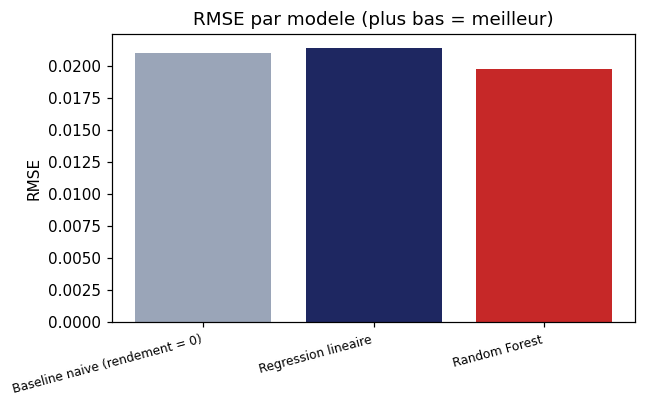

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.bar(resultats["Modele"], resultats["RMSE"], color=["#9AA5B8", "#1E2761", "#C62828"])
ax.set_title("RMSE par modele (plus bas = meilleur)")
plt.xticks(rotation=15, ha="right", fontsize=8)
plt.tight_layout()
plt.show()


## 4. Quelles variables comptent le plus ? (Random Forest)

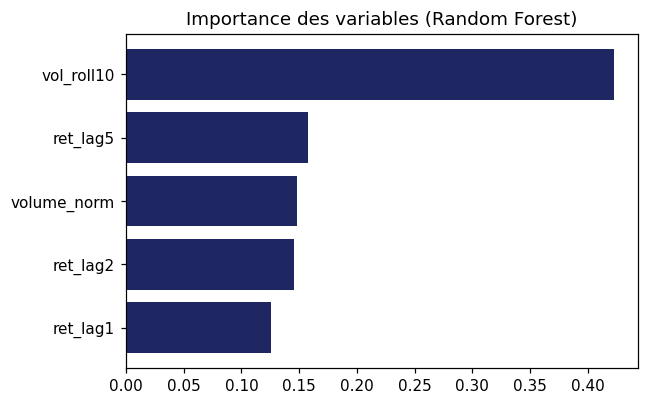

In [7]:
importances = pd.DataFrame({
    "Variable": features, "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.barh(importances["Variable"], importances["Importance"], color="#1E2761")
ax.invert_yaxis()
ax.set_title("Importance des variables (Random Forest)")
plt.tight_layout()
plt.show()


**Lecture :** la volatilité glissante (`vol_roll10`) domine largement l'importance des variables — cohérent avec la littérature financière : la volatilité récente est souvent plus prévisible que la direction du rendement lui-même (phénomène de "volatility clustering"). Les rendements décalés et le volume contribuent, mais dans une moindre mesure.

## Conclusion de cette étape

1. Sur cet échantillon réduit, le Random Forest fait légèrement mieux que la baseline naïve ; la régression linéaire fait moins bien.
2. L'écart reste **trop faible et l'échantillon trop petit (12 observations de test) pour en tirer une conclusion opérationnelle fiable.**
3. Cela confirme l'intuition de l'étape précédente : sur des rendements proches du bruit blanc, un modèle simple capte au mieux un signal marginal.
4. La suite logique n'est pas d'ajouter de la complexité (réseaux de neurones, plus de variables) mais de **tester si ce signal marginal a une quelconque valeur économique une fois les coûts de transaction pris en compte** — objet du notebook de backtesting.

**Limites :** échantillon simulé et réduit (60 observations utilisables après feature engineering) ; un vrai déploiement nécessiterait plusieurs années de données réelles et une validation croisée temporelle (walk-forward) plutôt qu'un split unique.
